## Business Question

How would different pricing decisions affect expected demand and revenue under alternative elasticity assumptions?

Rather than estimating the elasticity itself, this section translates the estimated demand model into pricing insights for decision makers.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cars = pd.read_csv("../data/cars.csv", encoding="latin1")
cars.columns = cars.columns.str.strip()

In [14]:
estimated_elasticity = -1.37

### Interpretation

The estimated price elasticity is approximately -1.37. This means that a 1% increase in price is associated with an estimated 1.37% decrease in quantity sold, holding other factors constant.

Because demand is elastic, broad price increases may reduce total revenue unless applied selectively to less price-sensitive segments.

In [15]:
price_changes = np.arange(-0.20, 0.25, 0.05)

results = []

for p in price_changes:

    demand_change = estimated_elasticity * p

    revenue_change = (1+p)*(1+demand_change)-1

    results.append({
        "Price Change (%)": p*100,
        "Demand Change (%)": demand_change*100,
        "Revenue Change (%)": revenue_change*100
    })

scenario = pd.DataFrame(results)

scenario

,Price Change (%),Demand Change (%),Revenue Change (%)
0,-2.000000e+01,2.740000e+01,1.9200
1,-1.500000e+01,2.055000e+01,2.4675
2,-1.000000e+01,1.370000e+01,2.3300
3,-5.000000e+00,6.850000e+00,1.5075
4,-5.551115e-15,7.605028e-15,0.0000
5,5.000000e+00,-6.850000e+00,-2.1925
6,1.000000e+01,-1.370000e+01,-5.0700
7,1.500000e+01,-2.055000e+01,-8.6325
8,2.000000e+01,-2.740000e+01,-12.8800


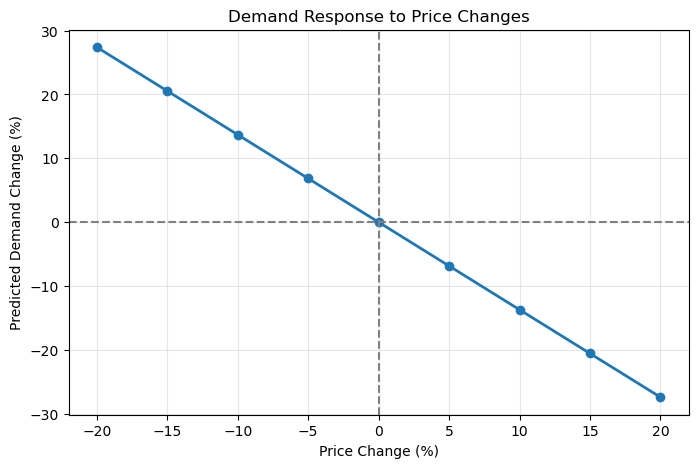

In [16]:
plt.figure(figsize=(8,5))

plt.plot(
    scenario["Price Change (%)"],
    scenario["Demand Change (%)"],
    marker="o",
    linewidth=2
)

plt.axhline(0,color="gray",linestyle="--")

plt.axvline(0,color="gray",linestyle="--")

plt.title("Demand Response to Price Changes")

plt.xlabel("Price Change (%)")

plt.ylabel("Predicted Demand Change (%)")

plt.grid(alpha=.3)

plt.show()

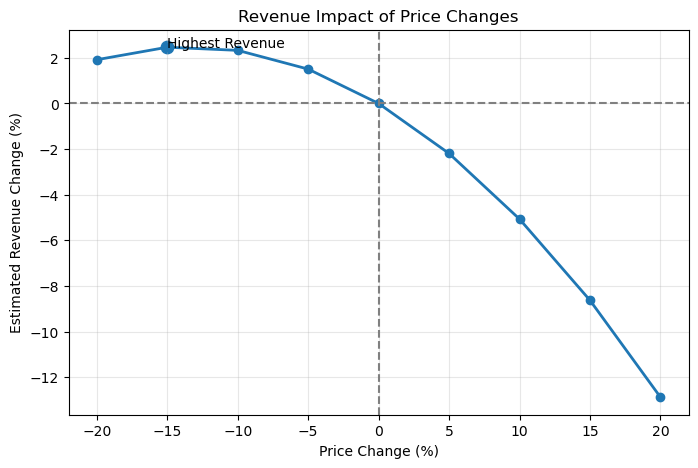

In [19]:
plt.figure(figsize=(8,5))

plt.plot(
    scenario["Price Change (%)"],
    scenario["Revenue Change (%)"],
    marker="o",
    linewidth=2
)

plt.axhline(0,color="gray",linestyle="--")

plt.axvline(0,color="gray",linestyle="--")

plt.title("Revenue Impact of Price Changes")

plt.xlabel("Price Change (%)")

plt.ylabel("Estimated Revenue Change (%)")

plt.grid(alpha=.3)

best = scenario.loc[
    scenario["Revenue Change (%)"].idxmax()
]

plt.scatter(
    best["Price Change (%)"],
    best["Revenue Change (%)"],
    s=80
)

plt.annotate(
    "Highest Revenue",
    (
        best["Price Change (%)"],
        best["Revenue Change (%)"]
    )
)

plt.show()

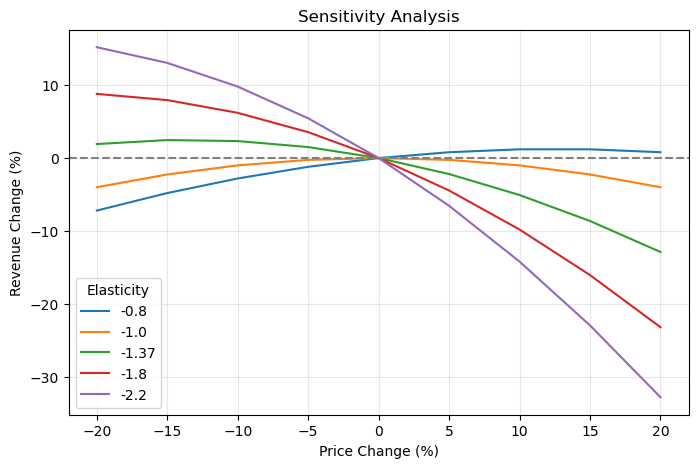

In [23]:
elasticities=[-0.8,-1.0,-1.37,-1.8,-2.2]

plt.figure(figsize=(8,5))

for e in elasticities:

    revenue=[]

    for p in price_changes:

        demand=e*p

        revenue.append(((1+p)*(1+demand)-1)*100)

    plt.plot(price_changes*100,revenue,label=f"{e}")


plt.legend(title="Elasticity")

plt.axhline(0,color="gray",linestyle="--")

plt.xlabel("Price Change (%)")

plt.ylabel("Revenue Change (%)")

plt.title("Sensitivity Analysis")

plt.grid(alpha=.3)

plt.show()

In [ ]:
df[df["cla"]==1]["brand"].value_counts()

brand
fiat           480
renault        384
citroen        351
rover          231
peugeot        200
VW             172
seat           139
nissan         138
lancia         133
ford           131
opel           104
suzuki         101
toyota          90
daihatsu        89
mazda           85
talbot          73
innocenti       57
audi            37
skoda           35
tal/simca       30
yugo            28
daf             28
honda           24
subaru          21
kia             19
hyundai          9
daewoo           8
volvo            6
MCC              4
tal/sunb         3
tal/hillman      1
Name: count, dtype: int64

### Key Findings

- Demand is highly responsive to price changes.

- Small price reductions may improve revenue because the increase in demand offsets the lower selling price.

- Large price increases are expected to reduce revenue under the estimated elasticity.

- Revenue recommendations are sensitive to the assumed elasticity, highlighting the importance of robust demand estimation.

### Managerial Recommendation

The results suggest avoiding uniform price increases across the product portfolio.

Instead, pricing decisions should be tailored to vehicle segments with different competitive intensity and willingness to pay.

Future work could estimate segment-specific elasticities for premium and mass-market brands separately.